In [1]:
#Import required packages
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import numpy as np
from sklearn.metrics import accuracy_score

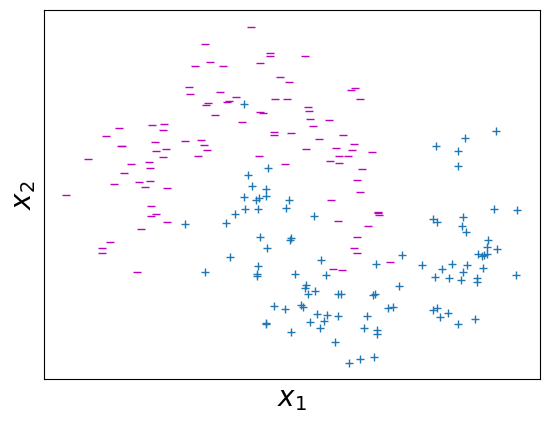

In [2]:
# Question 1, part a
X , y= make_moons(n_samples=200, noise=0.2, random_state=42)
# Visualize the dataset
# when the label is 1, the calss is represented as blue +
# when the label is 0, the class is represented as purple -
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "+")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "m_")

# X contains two features, x1 and x2
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$", fontsize=20)

plt.xticks([])
plt.yticks([])

# Displaying the plot.
plt.show()

# Splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, random_state=42)

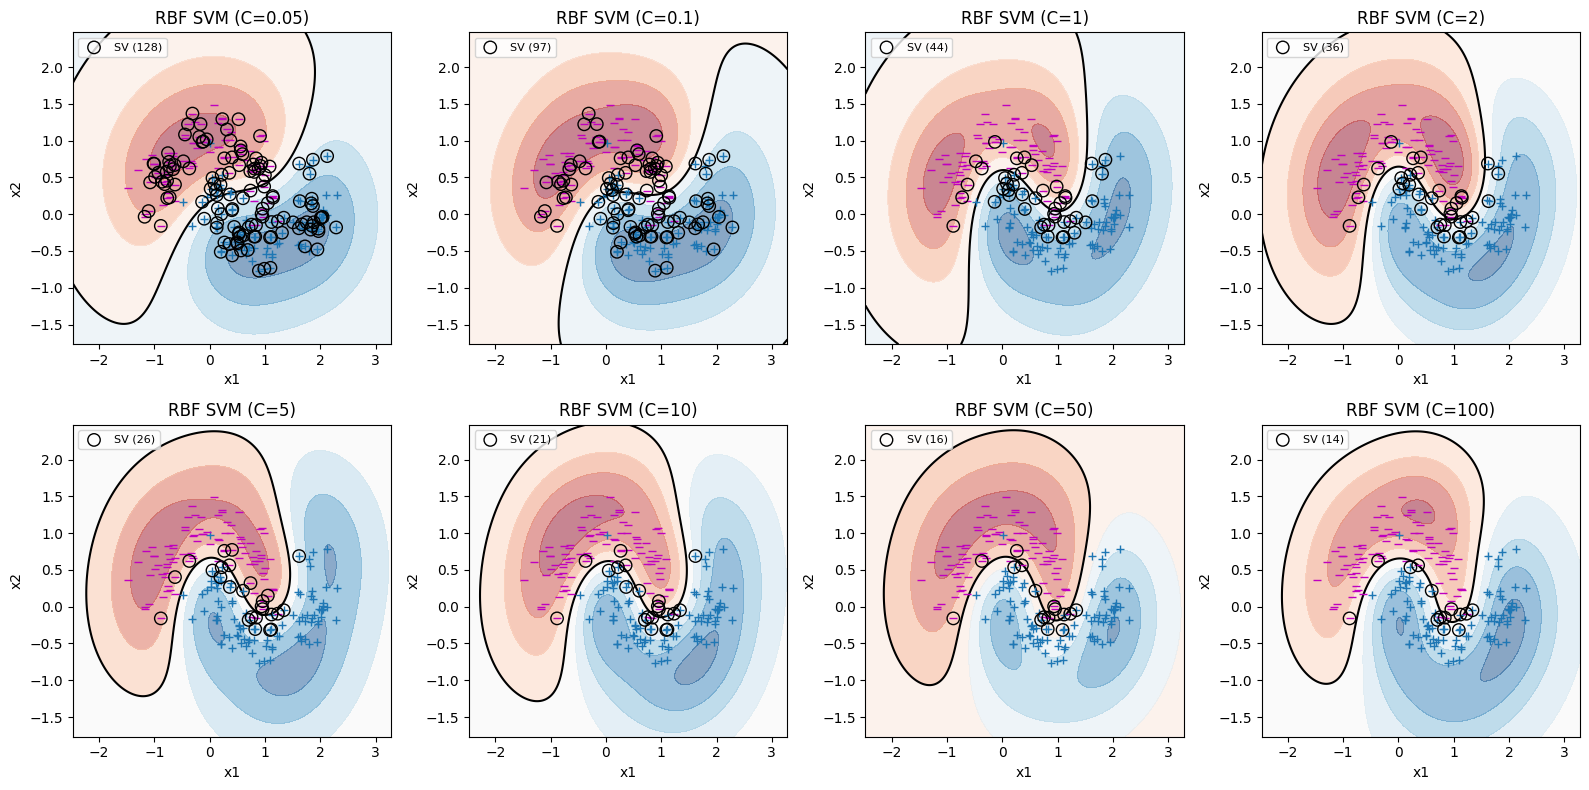

In [3]:
# Q1: part b
C_params=[0.05, 0.1, 1, 2, 5, 10, 50, 100]
plt.figure(figsize=(16, 8))
for i, C in enumerate(C_params,1):
    svm = SVC(random_state=42, kernel='rbf', C=C)
    # fit the data to svm classifier
    svm.fit(x_train, y_train)
    # Create a mesh to plot decision boundaries
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
    xy = np.vstack([xx.ravel(), yy.ravel()]).T
    # Plot decision boundary
    plt.subplot(2, 4, i)
    Z = svm.decision_function(xy).reshape(xx.shape)
    # Put the result into a contour plot
    plt.contourf(xx, yy, Z, cmap=plt.get_cmap("RdBu"), alpha=0.5, linestyles=["-"])
    # show decision boundary
    plt.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1.5)
    #plot dataset
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "+")
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "m_")
    #plot svms
    plt.scatter(svm.support_vectors_[:, 0],svm.support_vectors_[:, 1],
        s=80,
        facecolors="none",
        zorder=10,
        edgecolors="k", label=f'SV ({len(svm.support_vectors_)})')
    plt.title(f'RBF SVM (C={C})')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(fontsize=8, loc='upper left')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.tight_layout()
plt.show()

Choosing a larger value of C typically results in higher accuracy. The hyperparameter C controls how strongly the SVM penalizes misclassification of training examples. When C is large, the model prioritizes correctly classifying all training points, even if this leads to a smaller margin. In contrast, a small C encourages a wider margin, allowing more misclassifications in favor of a simpler decision boundary. If C is extremely small, the model may misclassify points even when the data is perfectly linearly separable.

Test accuracy for linear SVM: 0.8333333333333334
Test accuracy for poly SVM: 0.95
Test accuracy for rbf SVM: 0.9666666666666667
Test accuracy for sigmoid SVM: 0.6333333333333333


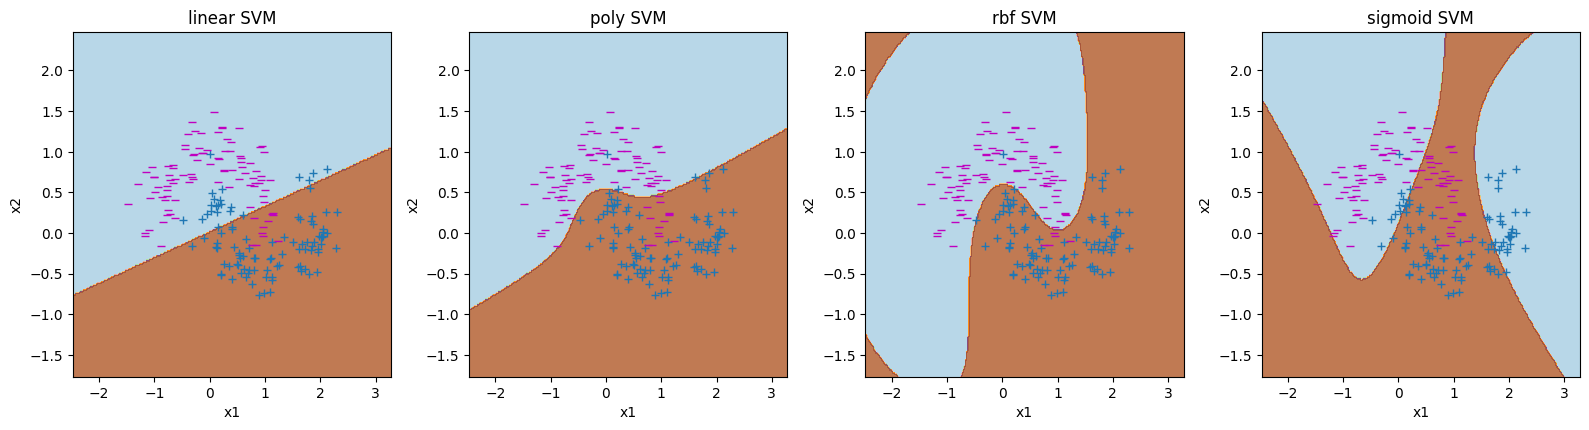

In [4]:
#Q 1: part c
kernel_name=['linear', 'poly', 'rbf', 'sigmoid']
plt.figure(figsize=(16, 8))
for i, kernel in enumerate(kernel_name,1):
  svm = SVC(random_state=42, kernel=kernel)
  svm.fit(x_train, y_train)
  # Create a mesh to plot decision boundaries
  h = 0.02  # step size in the mesh
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),np.arange(y_min, y_max, h))
  # Plot decision boundary
  plt.subplot(2, 4, i) # Changed grid size to 2 rows, 4 columns
  y_pred = svm.predict(np.c_[xx.ravel(), yy.ravel()])
  y_pred = y_pred.reshape(xx.shape)
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.Paired, alpha=0.8)
  #plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap=plt.cm.Paired)
  plt.plot(X[:, 0][y==1], X[:, 1][y==1], "+")
  plt.plot(X[:, 0][y==0], X[:, 1][y==0], "m_")
  plt.title(f'{kernel} SVM')
  plt.xlabel('x1') # Changed label for consistency with generated data
  plt.ylabel('x2') # Changed label for consistency with generated data
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  #test_accuracy
  y_pred_test=svm.predict(x_test)
  test_accuracy=accuracy_score(y_test, y_pred_test)
  print(f'Test accuracy for {kernel} SVM: {test_accuracy}')

plt.tight_layout()
plt.show()


Q1: part 1: The best test accuracy belonged to svm with kernel rbf

In [5]:
# Q2: part 2
# I read the section and I found this example for MLP as classifier by using sklearn package
from sklearn.neural_network import MLPClassifier
X = [[0., 0.], [1., 1.]]
y = [0, 1]
clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                    hidden_layer_sizes=(5, 2), random_state=1)
clf.fit(X, y)
clf.predict([[2., 2.], [-1., -2.]])

array([1, 0])

number of hidden nodes: 5 and the accuracy is: 0.8611
number of hidden nodes: 6 and the accuracy is: 0.8907
number of hidden nodes: 7 and the accuracy is: 0.8907
number of hidden nodes: 8 and the accuracy is: 0.9426
number of hidden nodes: 9 and the accuracy is: 0.8963
number of hidden nodes: 10 and the accuracy is: 0.9111
number of hidden nodes: 11 and the accuracy is: 0.9074
number of hidden nodes: 12 and the accuracy is: 0.9148
number of hidden nodes: 13 and the accuracy is: 0.95
number of hidden nodes: 14 and the accuracy is: 0.9315
number of hidden nodes: 15 and the accuracy is: 0.9704
number of hidden nodes: 16 and the accuracy is: 0.9741
number of hidden nodes: 17 and the accuracy is: 0.9556
number of hidden nodes: 18 and the accuracy is: 0.9574
number of hidden nodes: 19 and the accuracy is: 0.9556
number of hidden nodes: 20 and the accuracy is: 0.963
number of hidden nodes: 21 and the accuracy is: 0.9593
number of hidden nodes: 22 and the accuracy is: 0.9574
number of hidden n

Text(0.5, 1.0, 'Classification accuracy vs. number of hidden nodes')

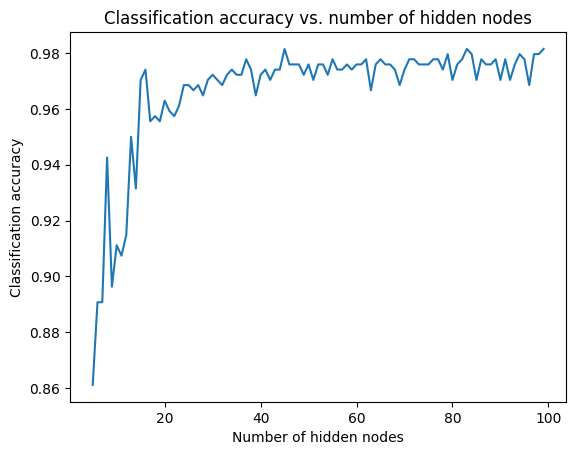

In [6]:
# Q2: part 3
from sklearn.datasets import load_digits
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np # Import numpy to use np.argmax

digits = load_digits()
X_train, X_test, Y_train, Y_test = train_test_split(digits.data, digits.target, train_size=0.7, test_size=0.3, random_state=42)
h_layer_size=range(5,100)
acc_score=[]
for i in h_layer_size:
    mlp = MLPClassifier(hidden_layer_sizes=(i,),
                        activation='logistic',
                        random_state=1,
                        alpha=1e-4,
                        max_iter=10000,
                        solver='sgd',
                        tol=1e-4,
                        learning_rate_init=.3,
                        verbose=False)
    mlp.fit(X_train, Y_train)
    predictions = mlp.predict(X_test)
    acc_score.append(accuracy_score(Y_test, predictions))
    print(f'number of hidden nodes: {i} and the accuracy is: {np.round(accuracy_score(Y_test, predictions),4)}')
# Corrected line: Use np.argmax to find the index of the maximum accuracy and get the corresponding hidden layer size
best_hidden_node_size = h_layer_size.start + np.argmax(acc_score)
print(f'The best size for hidden nodes is {best_hidden_node_size}')
#show the plot of classification accuracy vs the number of hidden nodes
plt.plot(h_layer_size, acc_score)
plt.xlabel('Number of hidden nodes')
plt.ylabel('Classification accuracy')
plt.title('Classification accuracy vs. number of hidden nodes')